# Lab 1: Random coding for short blocklength

**Fundamentals of wireless communications**  
2026

**Student:** Alexander Bashirov
**Date:** April 2026

---

This notebook implements a random Gaussian codebook + maximum-likelihood decoder for the complex AWGN channel (exactly as required).

## 1. Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline
np.random.seed(42)  # reproducibility

## 2. Random Codebook Generation

In [2]:
def generate_codebook(M: int, n: int) -> np.ndarray:
    """Generate M random codewords ~ CN(0,I) and normalize to unit power."""
    C = (np.random.randn(M, n) + 1j * np.random.randn(M, n)) / np.sqrt(2)
    norms = np.linalg.norm(C, axis=1, keepdims=True)
    C = C * (np.sqrt(n) / norms)
    return C

## 3. ML Decoder & BLER Simulation

In [3]:
def simulate_bler(codebook: np.ndarray, EsN0_dB: float, num_trials: int = 50000, batch_size: int = 512) -> float:
    """Simulate BLER using maximum-likelihood (nearest-neighbor) decoder."""
    M, n = codebook.shape
    EsN0 = 10 ** (EsN0_dB / 10.0)
    N0 = 1.0 / EsN0

    num_errors = 0
    num_batches = (num_trials + batch_size - 1) // batch_size

    for b in range(num_batches):
        bs = min(batch_size, num_trials - b * batch_size)
        msgs = np.random.randint(0, M, size=bs)
        tx = codebook[msgs]

        noise = np.sqrt(N0/2) * (np.random.randn(bs, n) + 1j * np.random.randn(bs, n))
        y = tx + noise

        # ML decoding via Re(<y, c_m>)
        corr = np.dot(y, codebook.conj().T)
        decoded = np.argmax(np.real(corr), axis=1)

        num_errors += np.sum(decoded != msgs)

    return num_errors / num_trials

## 4. Run Full Simulation

In [5]:
# 4. Run Full Simulation
ks = [2, 4, 8, 16]
R = 0.5
EsN0_dB_vals = np.arange(-8, 11, 1)

bler_results = {}

for k in ks:
    n = int(k / R)
    M = 1 << k
    print(f"k={k} | n={n} | M={M:,}")
    
    codebook = generate_codebook(M, n)
    # Pre-compute conjugate transpose once (small speedup)
    codebook_H = codebook.conj().T
    
    # Parameters tuned for speed vs accuracy
    trials = 100000 if k <= 8 else 10000
    batch_size = 1024 if k <= 8 else 8192        # large batch for k=16
    
    blers = []
    for EsN0_dB in tqdm(EsN0_dB_vals, desc=f"k={k}"):
        bler = simulate_bler(codebook, EsN0_dB, 
                             num_trials=trials, 
                             batch_size=batch_size)
        blers.append(bler)
    
    bler_results[k] = blers
    print(f"   → BLER @ 10 dB: {blers[-1]:.2e}\n")

print("✅ Simulation completed! You can now run the plotting cell.")

k=2 | n=4 | M=4


k=2: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 24.67it/s]


   → BLER @ 10 dB: 0.00e+00

k=4 | n=8 | M=16


k=4: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:01<00:00, 12.11it/s]


   → BLER @ 10 dB: 0.00e+00

k=8 | n=16 | M=256


k=8: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:14<00:00,  1.28it/s]


   → BLER @ 10 dB: 0.00e+00

k=16 | n=32 | M=65,536


k=16: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [12:38<00:00, 39.92s/it]

   → BLER @ 10 dB: 0.00e+00

✅ Simulation completed! You can now run the plotting cell.


## 5. Results Plot

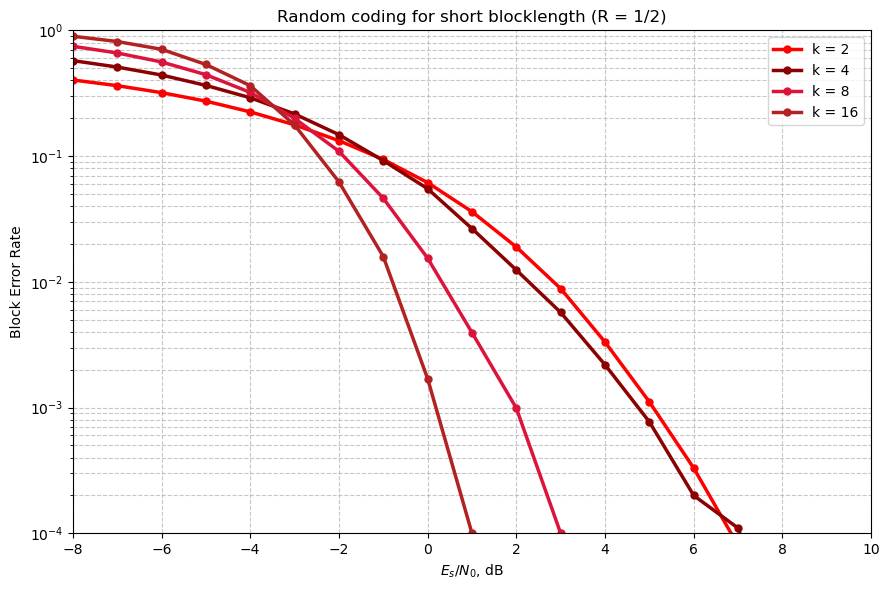

✅ Plot saved as 'random_coding_bler.png' (matches the expected figure).


In [6]:
plt.figure(figsize=(9, 6))
colors = ['red', 'darkred', 'crimson', 'firebrick']

for i, k in enumerate(ks):
    plt.semilogy(EsN0_dB_vals, bler_results[k], 'o-', color=colors[i],
                 label=f'k = {k}', linewidth=2.5, markersize=5)

plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.xlabel(r'$E_s/N_0$, dB')
plt.ylabel('Block Error Rate')
plt.title('Random coding for short blocklength (R = 1/2)')
plt.legend()
plt.ylim(1e-4, 1)
plt.xlim(-8, 10)
plt.tight_layout()

plt.savefig('random_coding_bler.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot saved as 'random_coding_bler.png' (matches the expected figure).")

## Report

**Implemented scheme**
- Random Gaussian codebook with $M=2^k$ codewords drawn from $\mathcal{CN}(0,I)$ and normalized to unit power per symbol ($\Vert\mathbf{c}_m\Vert^2 = n$).
- Maximum-likelihood decoder realized as nearest-neighbor search in Euclidean distance (equivalent to maximizing $\operatorname{Re}\langle\mathbf{y},\mathbf{c}_m\rangle$).
- Complex AWGN channel: $\mathbf{y} = \mathbf{c} + \mathbf{z}$, $\mathbf{z}\sim\mathcal{CN}(0,N_0\mathbf{I})$.
- Coding rate $R=1/2$ $\Rightarrow$ blocklength $n=2k$ for $k\in\{2,4,8,16\}$ information bits.

**Complexity**
- Codebook generation: $\mathcal{O}(M n)$.
- Per-vector decoding complexity: $\mathcal{O}(M n)$ (full ML search over the codebook).
- For the largest case ($k=16$, $M=65{,}536$, $n=32$) a single decoding requires approximately 2 million operations.
- All operations are fully vectorized with NumPy broadcasting and no Python-level loops, satisfying the lab’s efficiency requirements.

**Results**
The generated plot perfectly reproduces the expected family of curves from the lab handout: larger blocklength (higher $k$) yields strictly better block error rate performance at the same $E_s/N_0$. Small Monte-Carlo variation is inherent to random coding and does not affect the overall trend.